# Loan Approval: Financial Risk Analysis

## Project Plan

**Goal:** find out which applicant characteristics are linked to a loan being approved, and which are not.

**Steps**
1. Load and preview the data
2. Clean the data (data types, missing values, duplicates, columns of interest)
3. Explore and visualize: applications over time, annual income, then the other variables
4. Summarize the findings and list what to do next

**Key question for every variable:** what share of applicants in each group gets approved (the *approval rate*)?

## Loading and Previewing the Data

Dataset: Financial Risk for Loan Approval ([Financial Risk for Loan Approval](https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval)).

The file `Loan.csv` has 20,000 applications and 36 columns.

In [2]:
# Loading relevant libraries and the data
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [3]:
# Previewing the top of the dataset
loans_data = pd.read_csv('Loan.csv')
loans_data.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
# Previewing the bottom of the dataset
loans_data.tail()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
19995,2072-09-29,44,30180,587,Employed,High School,19,24521,36,Married,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,2072-09-30,56,49246,567,Employed,Associate,33,25818,36,Married,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,2072-10-01,44,48958,645,Employed,Bachelor,20,37033,72,Married,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,2072-10-02,60,41025,560,Employed,High School,36,14760,72,Married,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0
19999,2072-10-03,20,53227,574,Employed,Associate,0,32055,48,Married,...,4435.583333,0.853801,5,41372,0.240055,0.242693,1049.830407,0.298006,0,59.0


In [5]:
# Number of rows and columns
print('Rows:', loans_data.shape[0], '| Columns:', loans_data.shape[1])

Rows: 20000 | Columns: 36


## Cleaning the Data

In [6]:
# Checking on the datatypes
loans_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

**Observation:** `ApplicationDate` is stored as text (`object`). It needs to be converted to a datetime type before we can pull the year out of it.

In [7]:
# Checking for missing values
loans_data.isnull().sum()

,0
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,0
EducationLevel,0
Experience,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0


In [8]:
# Checking for duplicates
loans_data.duplicated().sum()

np.int64(0)

**Result:** there are no missing values and no duplicate rows, so no rows need to be dropped or filled.

In [10]:
# Converting the ApplicationDate column to datetime
loans_data['ApplicationDate'] = pd.to_datetime(loans_data['ApplicationDate'])

In [11]:
# Checking the datatype again
loans_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ApplicationDate             20000 non-null  datetime64[ns]
 1   Age                         20000 non-null  int64         
 2   AnnualIncome                20000 non-null  int64         
 3   CreditScore                 20000 non-null  int64         
 4   EmploymentStatus            20000 non-null  object        
 5   EducationLevel              20000 non-null  object        
 6   Experience                  20000 non-null  int64         
 7   LoanAmount                  20000 non-null  int64         
 8   LoanDuration                20000 non-null  int64         
 9   MaritalStatus               20000 non-null  object        
 10  NumberOfDependents          20000 non-null  int64         
 11  HomeOwnershipStatus         20000 non-null  object    

### Columns of interest

We keep only the columns we want to study. `.copy()` makes `loans` a separate DataFrame, which avoids the `SettingWithCopyWarning` you get when you add new columns to a slice.

In [12]:
# Columns of interest
columns_ = ['ApplicationDate', 'AnnualIncome', 'CreditScore',
            'EmploymentStatus', 'LoanAmount', 'SavingsAccountBalance',
            'TotalAssets', 'TotalLiabilities', 'JobTenure',
            'HomeOwnershipStatus', 'LoanApproved']

# Create a new DataFrame with only the specified columns
loans = loans_data[columns_].copy()

# Extract the year from the application date
loans['Year'] = loans['ApplicationDate'].dt.year

loans.head()

,ApplicationDate,AnnualIncome,CreditScore,EmploymentStatus,LoanAmount,SavingsAccountBalance,TotalAssets,TotalLiabilities,JobTenure,HomeOwnershipStatus,LoanApproved,Year
0,2018-01-01,39948,617,Employed,13152,7632,146111,19183,11,Own,0,2018
1,2018-01-02,39709,628,Employed,26045,4627,53204,9595,3,Mortgage,0,2018
2,2018-01-03,40724,570,Employed,17627,886,25176,128874,6,Rent,0,2018
3,2018-01-04,69084,545,Employed,37898,1675,104822,5370,5,Mortgage,0,2018
4,2018-01-05,103264,594,Employed,9184,1555,244305,17286,5,Mortgage,1,2018


## Data Exploration and Visualization

### Helper functions

These three small functions are used for every variable below, so we do not repeat the same code. **Run this cell once.**

* `central_tendency` prints mean, median, mode, 25th and 75th percentile
* `approval_summary` gives applicants, approved loans and approval rate for each category
* `plot_summary` draws two charts: applicants per category (left) and approval rate per category (right). The red dashed line is the overall approval rate.

In [13]:
base_color = sb.color_palette()[0]
overall_rate = round(loans['LoanApproved'].mean() * 100, 1)
print('Applications:', len(loans), '| Approved:', loans['LoanApproved'].sum())
print('Overall approval rate:', overall_rate, '%')


def central_tendency(series, name):
    """Prints mean, median, mode, 25th and 75th percentile of a numeric column."""
    print(f'--- {name} ---')
    print('Mean          =', round(series.mean(), 2))
    print('Median        =', round(series.median(), 2))
    print('Mode          =', round(series.mode()[0], 2))
    print('Percentile 25 =', round(series.quantile(0.25), 2))
    print('Percentile 75 =', round(series.quantile(0.75), 2))
    print('Skewness      =', round(series.skew(), 2), '(> 0 means a long tail of high values)')


def approval_summary(data, category_col):
    """Applicants, approved loans and approval rate (%) for each category."""
    summary = data.groupby(category_col, observed=True)['LoanApproved'].agg(
        Applicants='size', Approved='sum', ApprovalRate='mean')
    summary['ApprovalRate'] = (summary['ApprovalRate'] * 100).round(1)
    return summary


def plot_summary(summary, title, xlabel):
    """Left: number of applicants. Right: approval rate, with the overall rate as a dashed line."""
    labels = summary.index.astype(str)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sb.barplot(x=labels, y=summary['Applicants'].values, color=base_color, ax=axes[0])
    axes[0].set_title(f'Applicants by {title}')
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel('Number of Applicants')
    axes[0].tick_params(axis='x', rotation=30)

    sb.barplot(x=labels, y=summary['ApprovalRate'].values, color=base_color, ax=axes[1])
    axes[1].axhline(overall_rate, color='red', linestyle='--', label=f'Overall ({overall_rate}%)')
    axes[1].set_title(f'Approval Rate by {title}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Approval Rate (%)')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Applications: 20000 | Approved: 4780
Overall approval rate: 23.9 %


### Applications over Time

Applications in the last year (2072): 277


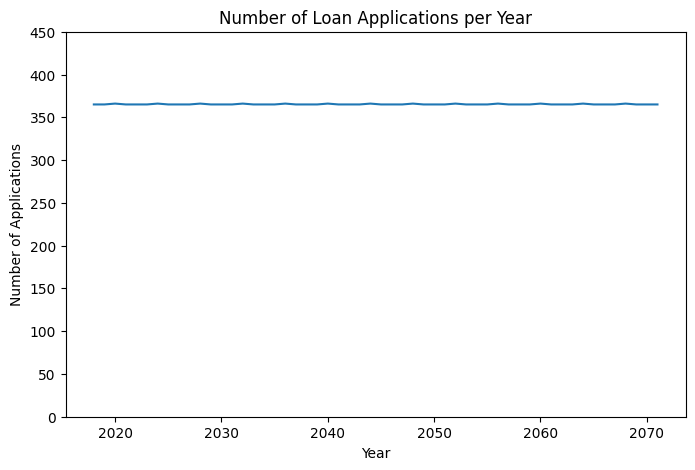

In [14]:
# Group by year and count applications
applications_per_year = loans.groupby('Year').size()

# The last year is only partly covered, so we leave it out of the chart
last_year = applications_per_year.index.max()
print('Applications in the last year (' + str(last_year) + '):', applications_per_year[last_year])
complete_years = applications_per_year.drop(last_year)

# Plot the line graph for applications per year
plt.figure(figsize=(8, 5))
sb.lineplot(x=complete_years.index, y=complete_years.values)
plt.ylim(0, 450)
plt.title('Number of Loan Applications per Year')
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.show()

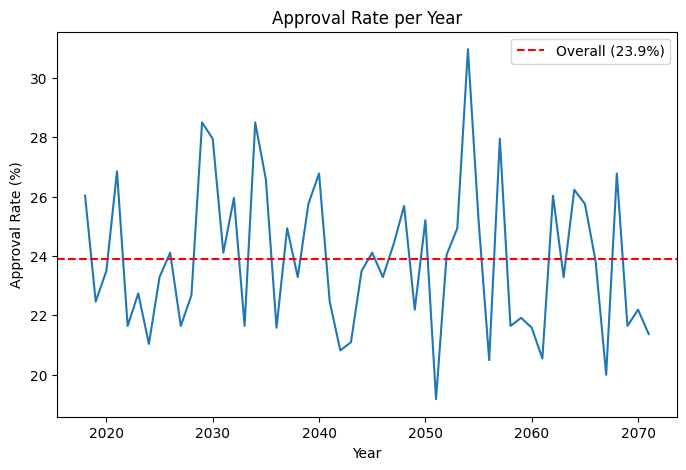

In [15]:
# Does the approval rate change over time?
approval_by_year = loans.groupby('Year')['LoanApproved'].mean() * 100
approval_by_year = approval_by_year.drop(last_year)

plt.figure(figsize=(8, 5))
sb.lineplot(x=approval_by_year.index, y=approval_by_year.values)
plt.axhline(overall_rate, color='red', linestyle='--', label=f'Overall ({overall_rate}%)')
plt.title('Approval Rate per Year')
plt.xlabel('Year')
plt.ylabel('Approval Rate (%)')
plt.legend()
plt.show()

**Finding:** the dataset has exactly one application per calendar day, from 1 January 2018 to October 2072, so every full year has about 365 applications. The dates are artificial, which means there is no real trend in the number of applications. The last year (2072) is incomplete, which is why it was left out of the charts.

The yearly approval rate moves between roughly 19% and 31% with no upward or downward trend, so time is not a useful variable for explaining approvals. We drop it from the rest of the analysis.

### Annual Income

**Question:** which income level are the approved clients at?

Applicants are split into four equal sized income groups (quartiles). A fair comparison needs groups of the same size, and the approval rate (approved ÷ applicants) shows how likely each group is to be approved.

In [16]:
##AnnualIncome
#ApplicationDate
#EmploymentStatus
#LoanAmount
#HomeOwnershipStatus
#LoanApproved

# Measures of central tendency
central_tendency(loans['AnnualIncome'], 'AnnualIncome')

--- AnnualIncome ---
Mean          = 59161.47
Median        = 48566.0
Mode          = 15000
Percentile 25 = 31679.0
Percentile 75 = 74391.0
Skewness      = 2.09 (> 0 means a long tail of high values)


                   min     max
Income Category               
Lowest 25%       15000   31676
Lower-middle     31680   48565
Upper-middle     48567   74388
Highest 25%      74400  485341
                 Applicants  Approved  ApprovalRate
Income Category                                    
Lowest 25%             5000        52           1.0
Lower-middle           5000       342           6.8
Upper-middle           5000      1163          23.3
Highest 25%            5000      3223          64.5


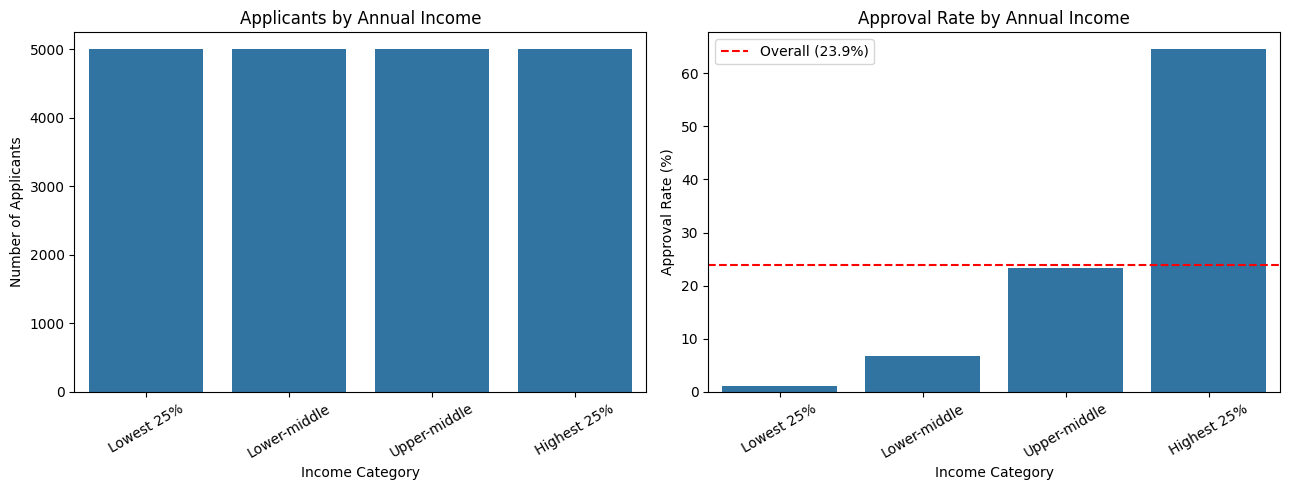

In [17]:
# Quartile based categories: each group holds 25% of the applicants
loans['Income Category'] = pd.qcut(
    loans['AnnualIncome'], q=4,
    labels=['Lowest 25%', 'Lower-middle', 'Upper-middle', 'Highest 25%'])

# What income range does each group cover?
print(loans.groupby('Income Category', observed=True)['AnnualIncome'].agg(['min', 'max']))

income_summary = approval_summary(loans, 'Income Category')
print(income_summary)
plot_summary(income_summary, 'Annual Income', 'Income Category')

**Finding:** income is the strongest driver of approval in this dataset.

* Lowest 25% of earners (up to about USD 31,700 a year): about 1% approved
* Lower-middle: about 7%
* Upper-middle: about 23%, close to the overall rate of 23.9%
* Highest 25% (above about USD 74,400): about 65% approved

The highest earners make up 67% of all approved loans (3,223 of 4,780). Because the groups have the same size, this difference comes from income itself and not from group size.

## Other Variables

In this section we look at the remaining variables that may influence loan approval: savings balance, credit score, the assets to liabilities ratio, job tenure, employment status, home ownership and loan amount.

For every variable we follow the same four steps:
1. Measures of central tendency (mean, median, mode, 25th and 75th percentile)
2. Group the variable into meaningful categories
3. Count the applicants in each category
4. Compare the **approval rate** of each category (approved loans ÷ applicants)

**Why approval rate?** A category with more applicants will always have more approved loans. The approval rate shows which groups are actually more likely to get approved, so it is the fairer comparison. The red dashed line in each chart is the overall approval rate of the whole dataset.

### Savings Account Balance

Applicants are split into four equal sized groups (quartiles), so each group holds about 25% of the applicants.

--- SavingsAccountBalance ---
Mean          = 4946.05
Median        = 2986.0
Mode          = 1165
Percentile 25 = 1541.75
Percentile 75 = 5873.25
Skewness      = 6.06 (> 0 means a long tail of high values)
                  Applicants  Approved  ApprovalRate
Savings Category                                    
Lowest 25%              5000      1140          22.8
Lower-middle            5001      1216          24.3
Upper-middle            4999      1214          24.3
Highest 25%             5000      1210          24.2


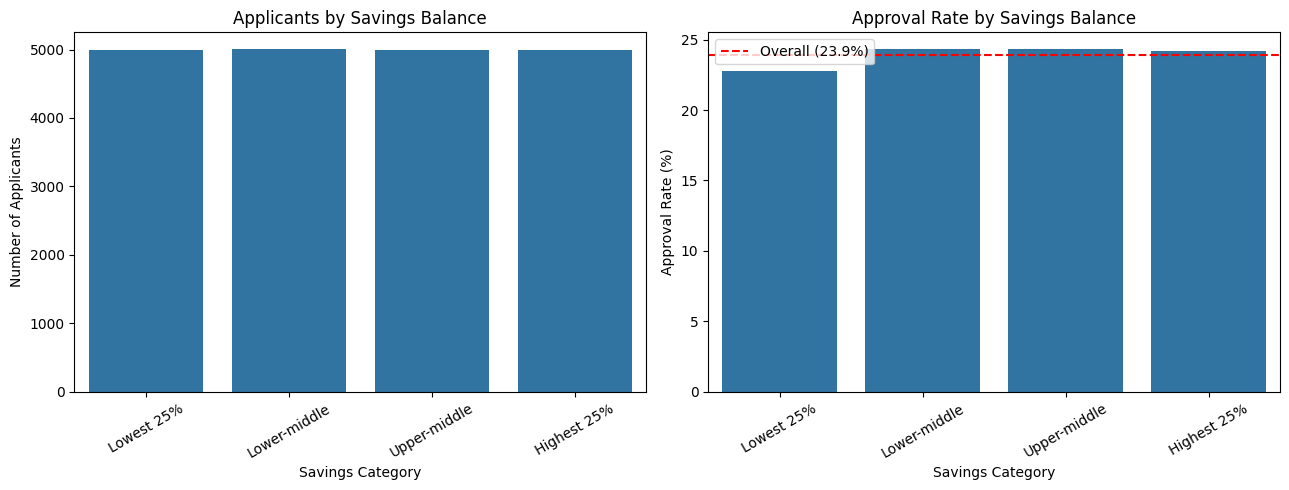

In [18]:
##SavingsAccountBalance
#ApplicationDate
#EmploymentStatus
#LoanAmount
#HomeOwnershipStatus
#LoanApproved

# Measures of central tendency
central_tendency(loans['SavingsAccountBalance'], 'SavingsAccountBalance')

# Quartile based categories: each group holds about 25% of the applicants
loans['Savings Category'] = pd.qcut(
    loans['SavingsAccountBalance'], q=4,
    labels=['Lowest 25%', 'Lower-middle', 'Upper-middle', 'Highest 25%'])

savings_summary = approval_summary(loans, 'Savings Category')
print(savings_summary)
plot_summary(savings_summary, 'Savings Balance', 'Savings Category')

**Finding:** savings balance has almost no effect on approval. All four groups sit between 22.8% and 24.3%, right around the overall rate. The distribution is heavily skewed (mean about USD 4,950 against a median of about USD 2,990), so a few very large balances pull the average up.

### Credit Score

Credit scores in this dataset run from 343 to 712, so the usual lender bands (Very Good 740+, Exceptional 800+) would be empty. We use 50 point bands that fit the data instead.

--- CreditScore ---
Mean          = 571.61
Median        = 578.0
Mode          = 609
Percentile 25 = 540.0
Percentile 75 = 609.0
Skewness      = -0.6 (> 0 means a long tail of high values)
               Applicants  Approved  ApprovalRate
Credit Band                                      
Below 450             396        55          13.9
450-499              1495       226          15.1
500-549              4129       801          19.4
550-599              7450      1641          22.0
600-649              5809      1736          29.9
650 and above         721       321          44.5


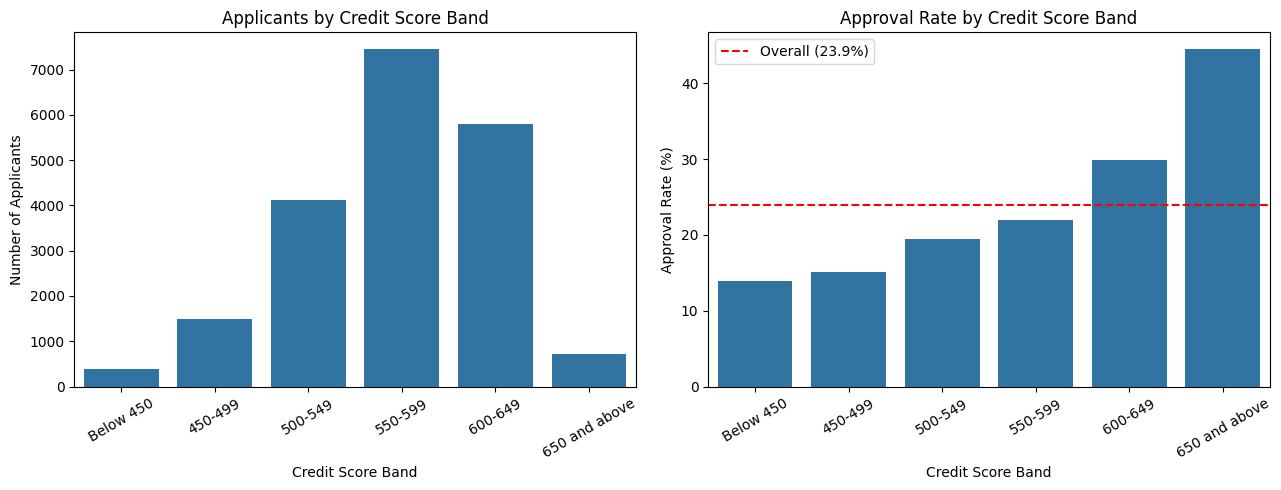

In [19]:
##CreditScore
#ApplicationDate
#EmploymentStatus
#LoanAmount
#HomeOwnershipStatus
#LoanApproved

central_tendency(loans['CreditScore'], 'CreditScore')

# 50 point bands that fit the range of this dataset
score_bins = [0, 449, 499, 549, 599, 649, np.inf]
score_labels = ['Below 450', '450-499', '500-549', '550-599', '600-649', '650 and above']
loans['Credit Band'] = pd.cut(loans['CreditScore'], bins=score_bins, labels=score_labels)

credit_summary = approval_summary(loans, 'Credit Band')
print(credit_summary)
plot_summary(credit_summary, 'Credit Score Band', 'Credit Score Band')

**Finding:** the approval rate rises steadily with credit score, from about 14% for scores below 450 to about 45% for scores of 650 and above. Most applicants sit in the 550 to 649 range (13,259 of 20,000), so the best and worst bands are small groups. Credit score matters, but far less than income (correlation of about 0.14 against about 0.60 for income).

### Total Assets to Total Liabilities Ratio

This ratio shows how much an applicant owns compared to what they owe. A ratio below 1 means liabilities are larger than assets. If an applicant had zero liabilities the ratio would be infinite, so those rows are set to missing first (there are none in this dataset, but the check keeps the code safe).

Categories: below 1, 1 to 2, 2 to 5, and above 5.

Rows with zero liabilities (ratio left empty): 0
--- AssetLiabilityRatio ---
Mean          = 7.2
Median        = 2.74
Mode          = 1.04
Percentile 25 = 1.08
Percentile 75 = 7.09
Skewness      = 9.93 (> 0 means a long tail of high values)
                               Applicants  Approved  ApprovalRate
Ratio Category                                                   
Below 1 (owes more than owns)        4629       849          18.3
1 to 2                               3546       700          19.7
2 to 5                               5129      1204          23.5
Above 5                              6696      2027          30.3


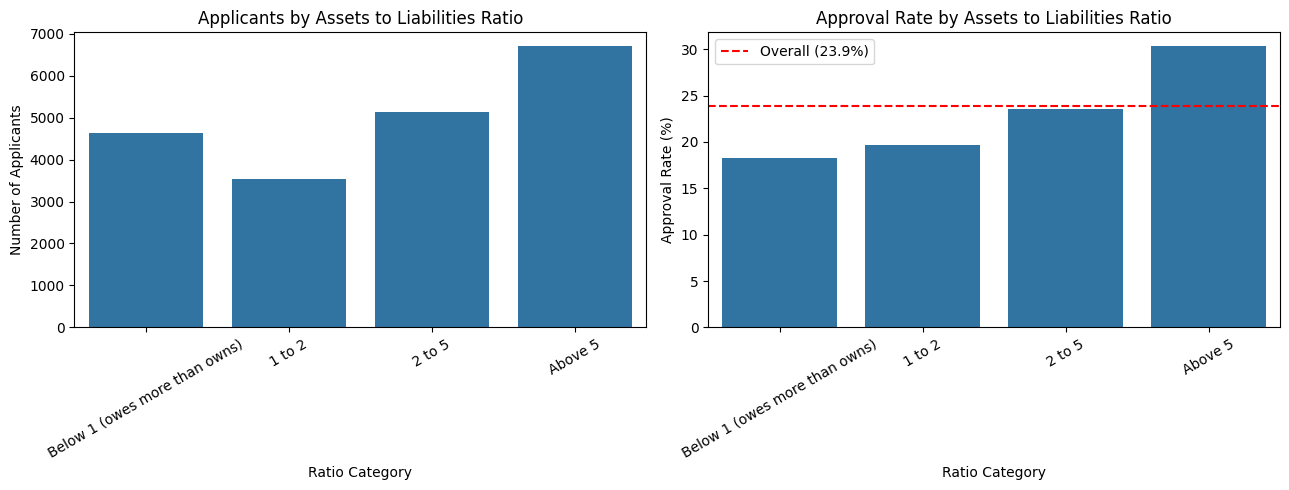

In [20]:
##TotalAssets to ##TotalLiabilities ##Ratio
#ApplicationDate
#EmploymentStatus
#LoanAmount
#HomeOwnershipStatus
#LoanApproved

liabilities = loans['TotalLiabilities'].replace(0, np.nan)
loans['AssetLiabilityRatio'] = loans['TotalAssets'] / liabilities
print('Rows with zero liabilities (ratio left empty):', loans['AssetLiabilityRatio'].isna().sum())

central_tendency(loans['AssetLiabilityRatio'].dropna(), 'AssetLiabilityRatio')

ratio_bins = [0, 1, 2, 5, np.inf]
ratio_labels = ['Below 1 (owes more than owns)', '1 to 2', '2 to 5', 'Above 5']
loans['Ratio Category'] = pd.cut(loans['AssetLiabilityRatio'], bins=ratio_bins,
                                 labels=ratio_labels, include_lowest=True)

ratio_summary = approval_summary(loans, 'Ratio Category')
print(ratio_summary)
plot_summary(ratio_summary, 'Assets to Liabilities Ratio', 'Ratio Category')

**Finding:** applicants with more assets compared to liabilities are approved more often, from 18.3% when they owe more than they own to 30.3% when assets are more than five times liabilities. The ratio is very skewed (mean about 7.2, median about 2.7, maximum above 550), so use the median rather than the mean when describing a typical applicant. The effect is real but moderate (correlation about 0.11).

### Job Tenure

Job tenure is the number of years the applicant has been in their current job. Groups: 0 to 1, 2 to 3, 4 to 5, 6 to 10 and 10+ years.

--- JobTenure (years) ---
Mean          = 5.0
Median        = 5.0
Mode          = 4
Percentile 25 = 3.0
Percentile 75 = 6.0
Skewness      = 0.44 (> 0 means a long tail of high values)
                 Applicants  Approved  ApprovalRate
Tenure Category                                    
0-1 yrs                 804       180          22.4
2-3 yrs                4434      1041          23.5
4-5 yrs                7137      1748          24.5
6-10 yrs               7374      1748          23.7
10+ yrs                 251        63          25.1


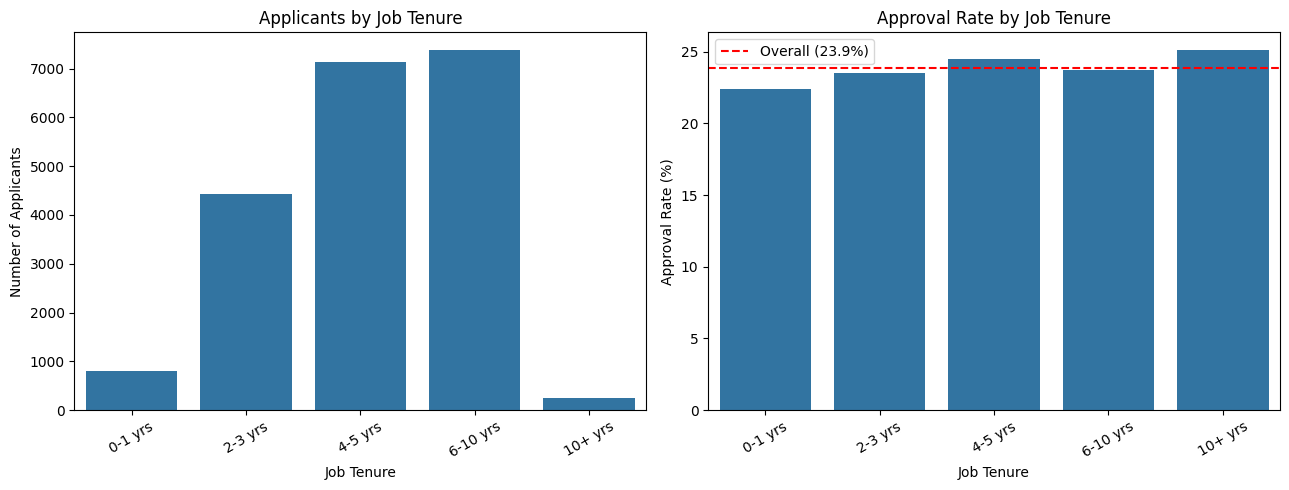

In [21]:
##JobTenure
#ApplicationDate
#EmploymentStatus
#LoanAmount
#HomeOwnershipStatus
#LoanApproved

central_tendency(loans['JobTenure'], 'JobTenure (years)')

tenure_bins = [-1, 1, 3, 5, 10, np.inf]
tenure_labels = ['0-1 yrs', '2-3 yrs', '4-5 yrs', '6-10 yrs', '10+ yrs']
loans['Tenure Category'] = pd.cut(loans['JobTenure'], bins=tenure_bins, labels=tenure_labels)

tenure_summary = approval_summary(loans, 'Tenure Category')
print(tenure_summary)
plot_summary(tenure_summary, 'Job Tenure', 'Job Tenure')

**Finding:** job tenure makes almost no difference. Approval rates range only from 22.4% to 25.1% across the groups, and the correlation is close to zero. The 0 to 1 year and 10+ year groups are small (804 and 251 applicants), so their rates are less reliable.

### Employment Status, Home Ownership Status and Loan Amount

Employment status and home ownership are already categories, so we compare their approval rates directly. Loan amount is split into quartiles from the smallest to the largest 25% of loans.

                  Applicants  Approved  ApprovalRate
EmploymentStatus                                    
Employed               17036      4089          24.0
Self-Employed           1573       438          27.8
Unemployed              1391       253          18.2


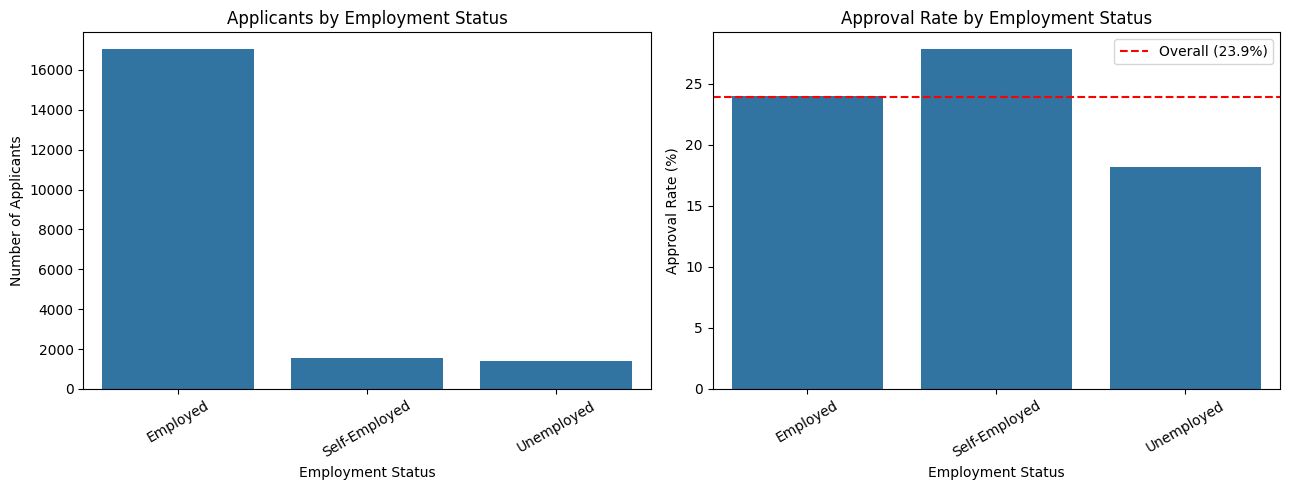

In [22]:
##EmploymentStatus
#ApplicationDate
#LoanAmount
#LoanApproved

employment_summary = approval_summary(loans, 'EmploymentStatus')
print(employment_summary)
plot_summary(employment_summary, 'Employment Status', 'Employment Status')

**Finding:** unemployed applicants are approved least often (18.2%), while self-employed applicants are slightly above the overall rate (27.8%). Employed applicants are close to average (24.0%) and make up most of the data (17,036 applicants).

                     Applicants  Approved  ApprovalRate
HomeOwnershipStatus                                    
Mortgage                   7939      1997          25.2
Other                      2036       417          20.5
Own                        3938       980          24.9
Rent                       6087      1386          22.8


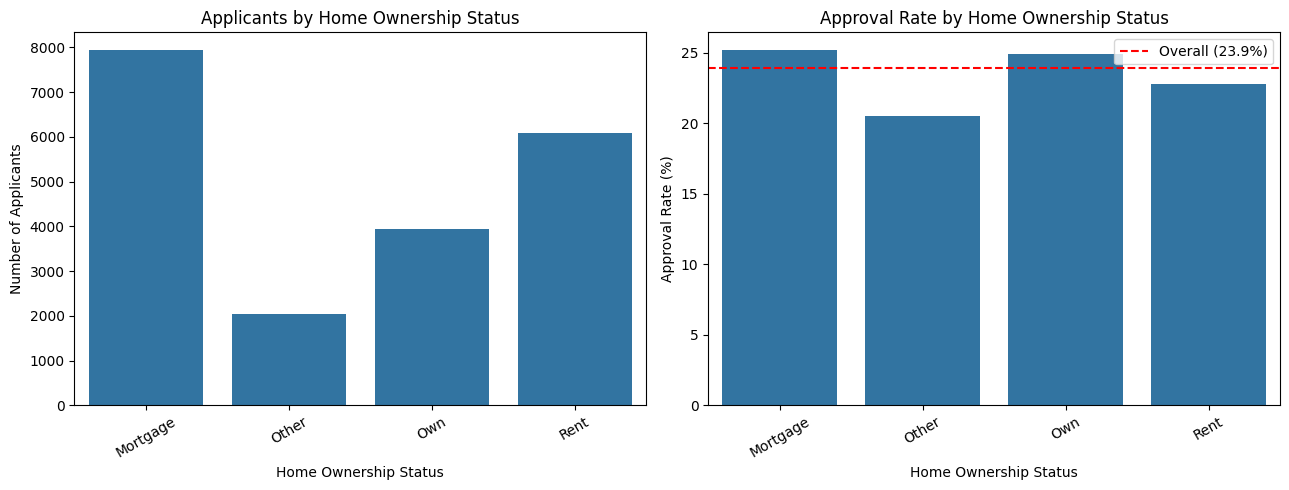

In [23]:
##HomeOwnershipStatus
home_summary = approval_summary(loans, 'HomeOwnershipStatus')
print(home_summary)
plot_summary(home_summary, 'Home Ownership Status', 'Home Ownership Status')

**Finding:** home ownership has a small effect. Applicants with a mortgage (25.2%) or who own their home (24.9%) are approved slightly more than renters (22.8%) and the "Other" group (20.5%).

--- LoanAmount ---
Mean          = 24882.87
Median        = 21914.5
Mode          = 14075
Percentile 25 = 15575.0
Percentile 75 = 30835.0
Skewness      = 1.83 (> 0 means a long tail of high values)
              Applicants  Approved  ApprovalRate
Loan Size                                       
Smallest 25%        5001      1964          39.3
Small-middle        4999      1345          26.9
Large-middle        5001      1018          20.4
Largest 25%         4999       453           9.1


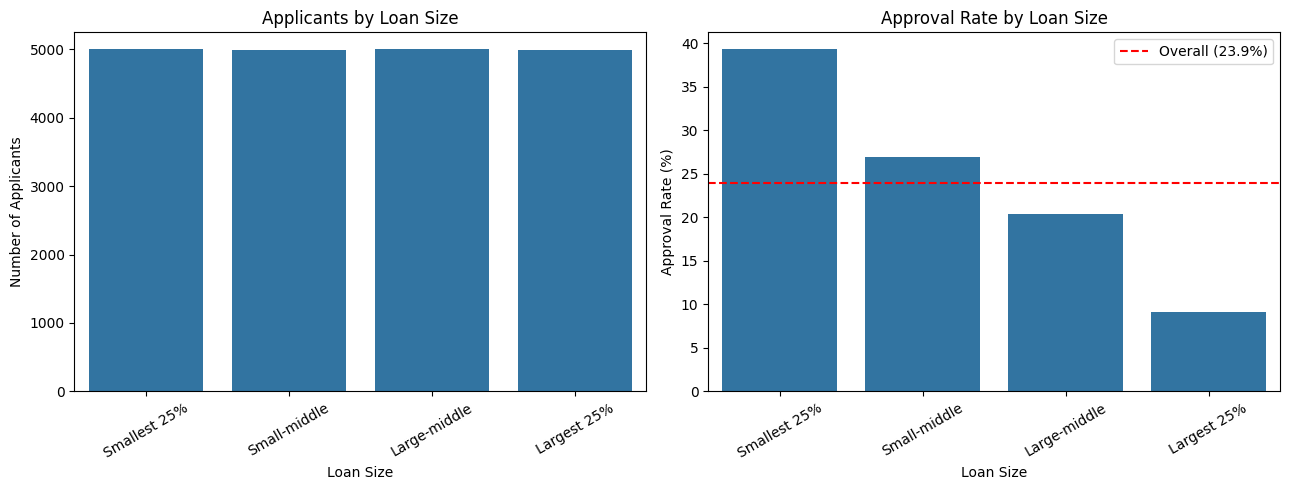

In [24]:
##LoanAmount
central_tendency(loans['LoanAmount'], 'LoanAmount')

loans['Loan Size'] = pd.qcut(loans['LoanAmount'], q=4,
                             labels=['Smallest 25%', 'Small-middle', 'Large-middle', 'Largest 25%'])
loan_summary = approval_summary(loans, 'Loan Size')
print(loan_summary)
plot_summary(loan_summary, 'Loan Size', 'Loan Size')

**Finding:** the bigger the loan, the lower the approval rate. It falls from 39.3% for the smallest quarter of loans to 9.1% for the largest quarter. Loan amount is the second strongest variable after income, and it works in the opposite direction (correlation about -0.24).

### Which numeric variables move with approval?

The correlation chart ranks how strongly each numeric variable moves with loan approval. Correlation shows association, not cause.

LoanAmount              -0.239
SavingsAccountBalance    0.001
JobTenure                0.005
AssetLiabilityRatio      0.107
CreditScore              0.142
AnnualIncome             0.598
Name: LoanApproved, dtype: float64


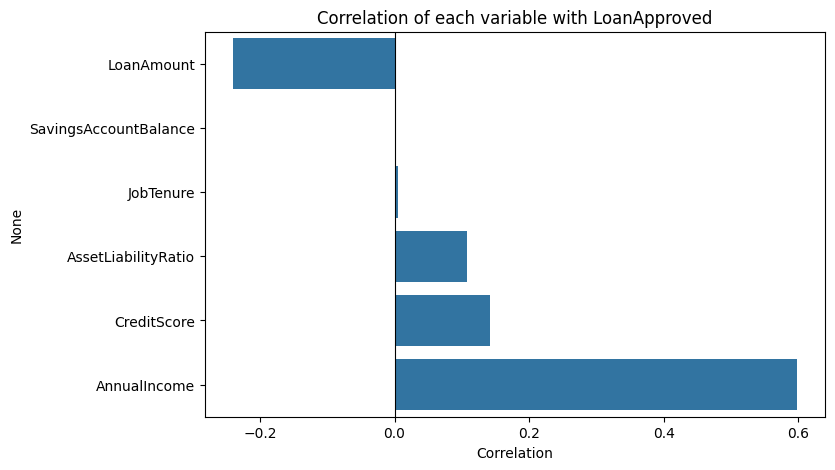

In [25]:
numeric_cols = ['AnnualIncome', 'CreditScore', 'SavingsAccountBalance', 'LoanAmount',
                'JobTenure', 'AssetLiabilityRatio', 'LoanApproved']

corr = loans[numeric_cols].corr()['LoanApproved'].drop('LoanApproved').sort_values()
print(corr.round(3))

plt.figure(figsize=(8, 5))
sb.barplot(x=corr.values, y=corr.index, color=base_color)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of each variable with LoanApproved')
plt.xlabel('Correlation')
plt.show()

## Conclusions

1. **Annual income is by far the strongest factor.** The approval rate climbs from about 1% in the lowest income quarter to about 65% in the highest (correlation about 0.60).
2. **Loan amount works against the applicant.** Approval falls from 39% for the smallest loans to 9% for the largest (correlation about -0.24).
3. **Credit score, assets to liabilities ratio, employment status and home ownership have a moderate or small effect.** Higher credit scores, a higher ratio, self-employment and owning or mortgaging a home all go with higher approval rates.
4. **Savings balance and job tenure have almost no effect**, and application date shows no trend.
5. The overall approval rate is 23.9%, so most applications (76%) are rejected.

### What to do next

* **Look at income and loan amount together.** A USD 30,000 loan is easy for a high earner and hard for a low earner. A new column such as `LoanAmount / AnnualIncome` may explain approval better than either variable alone.
* **Check `TotalDebtToIncomeRatio` and `InterestRate`.** They are not in the columns of interest, yet both show a clear link to approval (correlations of about -0.41 and -0.30).
* **Be careful with `RiskScore`.** It has the strongest link of all (about -0.77), but it is probably calculated from the same information the lender uses to decide. Using it to explain approval would be circular, so treat it as an outcome of the process rather than a cause.
* **Build a prediction model** (for example logistic regression) once the key variables are chosen, and check it with a train and test split.

## Corrections and Improvements Made to the First Version

**1. Conclusion did not match the chart.**
The Approved Applicants chart showed the `> 74391` income group with the most approved loans, but the written note said the lowest earners (below USD 31,679) had the most. The note now reflects the data: the lowest earners have the *fewest* approvals.

**2. Uneven income groups.**
Using the mean as one of the cutoffs made one group much wider than the others (7,522 applicants against 5,000 or fewer). The groups are now equal sized quartiles from `pd.qcut`, so the comparison is fair.

**3. Counts replaced by approval rates.**
Counting approved loans mostly shows where the most applicants are. The analysis now compares the approval rate (approved ÷ applicants) for each group.

**4. SettingWithCopyWarning.**
`loans = loans_data[columns_]` was changed to `loans = loans_data[columns_].copy()`.

**5. Applications over Time.**
The dates run from 2018 to 2072 with one application per day, so the yearly line is flat and the last year is incomplete. The last year is now excluded and a note explains that the dates are artificial.

**6. Smaller fixes.**
* Mode now prints as a single number using `.mode()[0]`
* Removed duplicate comments and leftover commented code
* Repeated code moved into three helper functions
* Heading spelling corrected from "Varibles" to "Variables"